In [ ]:
!pip install pyspark

In [ ]:
from pyspark.sql import SparkSession
from pyspark import SparkContext
spark = SparkSession.builder.appName('retailtest').getOrCreate()
sc = SparkContext.getOrCreate()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
sc

<SparkContext master=local[*] appName=retailtest>

In [ ]:
categories_rdd = sc.textFile("/retaildb_categories")
customers_rdd = sc.textFile("/retaildb_customers")
departments_rdd = sc.textFile("/retaildb_departments")
orders_rdd = sc.textFile("/orders_1gb.csv")
order_items_rdd = sc.textFile("/retaildb_order_items")
products_rdd = sc.textFile("/retaildb_products")

In [ ]:
print(categories_rdd.take(5))
print(customers_rdd.take(5))
print(departments_rdd.take(5))
print(orders_rdd.take(5))
print(order_items_rdd.take(5))
print(products_rdd.take(5))

['1,2,Football', '2,2,Soccer', '3,2,Baseball & Softball', '4,2,Basketball', '5,2,Lacrosse']
['1,Richard,Hernandez,XXXXXXXXX,XXXXXXXXX,6303 Heather Plaza,Brownsville,TX,78521', '2,Mary,Barrett,XXXXXXXXX,XXXXXXXXX,9526 Noble Embers Ridge,Littleton,CO,80126', '3,Ann,Smith,XXXXXXXXX,XXXXXXXXX,3422 Blue Pioneer Bend,Caguas,PR,00725', '4,Mary,Jones,XXXXXXXXX,XXXXXXXXX,8324 Little Common,San Marcos,CA,92069', '5,Robert,Hudson,XXXXXXXXX,XXXXXXXXX,"10 Crystal River Mall ",Caguas,PR,00725']
['2,Fitness', '3,Footwear', '4,Apparel', '5,Golf', '6,Outdoors']
['1,2013-07-25 00:00:00.0,11599,CLOSED', '2,2013-07-25 00:00:00.0,256,PENDING_PAYMENT', '3,2013-07-25 00:00:00.0,12111,COMPLETE', '4,2013-07-25 00:00:00.0,8827,CLOSED', '5,2013-07-25 00:00:00.0,11318,COMPLETE']
['1,1,957,1,299.98,299.98', '2,2,1073,1,199.99,199.99', '3,2,502,5,250.0,50.0', '4,2,403,1,129.99,129.99', '5,4,897,2,49.98,24.99']
['1,2,Quest Q64 10 FT. x 10 FT. Slant Leg Instant U,,59.98,http://images.acmesports.sports/Quest+Q64+10+FT

Creating RDDs from raw data and mapping key-rows

In [ ]:
categories_rdd_mapped = categories_rdd.map(lambda line: line.split(",")).map(lambda x: (int(x[0]), x))  # Mapping by category_id
customers_rdd_mapped = customers_rdd.map(lambda line: line.split(",")).map(lambda x: (int(x[0]), x))   # Mapping by customer_id
departments_rdd_mapped = departments_rdd.map(lambda line: line.split(",")).map(lambda x: (int(x[0]), x))  # Mapping by department_id
orders_rdd_mapped = orders_rdd.map(lambda line: line.split(",")).map(lambda x: (int(x[0]), x))   # Mapping by order_id
order_items_rdd_mapped = order_items_rdd.map(lambda line: line.split(",")).map(lambda x: (int(x[1]), x))  # Mapping by order_item_id (use x[1] for order_id)
products_rdd_mapped = products_rdd.map(lambda line: line.split(",")).map(lambda x: (int(x[0]), x))   # Mapping by product_id

RDD to Datafraem conversion with explicit column mapping

In [ ]:
from pyspark.sql import Row

# Split RDD and map it to Row objects
customers_rdd_mapped = customers_rdd.map(lambda line: line.split(",")).map(lambda x: Row(
    cust_id=int(x[0]),
    fname=x[1],
    lname=x[2],
    unknown_1=x[3],
    unknown_2=x[4],
    address=x[5],
    city=x[6],
    state=x[7],
    value=float(x[8])
))

# Convert to DataFrame
customers_df = customers_rdd_mapped.toDF()
customers_df.show()

+-------+-----------+---------+---------+---------+--------------------+-------------+-----+-------+
|cust_id|      fname|    lname|unknown_1|unknown_2|             address|         city|state|  value|
+-------+-----------+---------+---------+---------+--------------------+-------------+-----+-------+
|      1|    Richard|Hernandez|XXXXXXXXX|XXXXXXXXX|  6303 Heather Plaza|  Brownsville|   TX|78521.0|
|      2|       Mary|  Barrett|XXXXXXXXX|XXXXXXXXX|9526 Noble Embers...|    Littleton|   CO|80126.0|
|      3|        Ann|    Smith|XXXXXXXXX|XXXXXXXXX|3422 Blue Pioneer...|       Caguas|   PR|  725.0|
|      4|       Mary|    Jones|XXXXXXXXX|XXXXXXXXX|  8324 Little Common|   San Marcos|   CA|92069.0|
|      5|     Robert|   Hudson|XXXXXXXXX|XXXXXXXXX|"10 Crystal River...|       Caguas|   PR|  725.0|
|      6|       Mary|    Smith|XXXXXXXXX|XXXXXXXXX|3151 Sleepy Quail...|      Passaic|   NJ| 7055.0|
|      7|    Melissa|   Wilcox|XXXXXXXXX|XXXXXXXXX|9453 High Concession|       Caguas|   PR

In [ ]:
orders_rdd_mapped = orders_rdd.map(lambda line: line.split(",")).map(lambda x: Row(
    order_id=int(x[0]),
    timestamp=x[1],
    value=float(x[2]),
    status=x[3]
))

orders_df = orders_rdd_mapped.toDF()
orders_df.show()


+--------+--------------------+-------+---------------+
|order_id|           timestamp|  value|         status|
+--------+--------------------+-------+---------------+
|       1|2013-07-25 00:00:...|11599.0|         CLOSED|
|       2|2013-07-25 00:00:...|  256.0|PENDING_PAYMENT|
|       3|2013-07-25 00:00:...|12111.0|       COMPLETE|
|       4|2013-07-25 00:00:...| 8827.0|         CLOSED|
|       5|2013-07-25 00:00:...|11318.0|       COMPLETE|
|       6|2013-07-25 00:00:...| 7130.0|       COMPLETE|
|       7|2013-07-25 00:00:...| 4530.0|       COMPLETE|
|       8|2013-07-25 00:00:...| 2911.0|     PROCESSING|
|       9|2013-07-25 00:00:...| 5657.0|PENDING_PAYMENT|
|      10|2013-07-25 00:00:...| 5648.0|PENDING_PAYMENT|
|      11|2013-07-25 00:00:...|  918.0| PAYMENT_REVIEW|
|      12|2013-07-25 00:00:...| 1837.0|         CLOSED|
|      13|2013-07-25 00:00:...| 9149.0|PENDING_PAYMENT|
|      14|2013-07-25 00:00:...| 9842.0|     PROCESSING|
|      15|2013-07-25 00:00:...| 2568.0|       CO

In [ ]:
order_items_rdd_mapped = order_items_rdd.map(lambda line: line.split(",")).map(lambda x: Row(
    id=int(x[0]),
    order_id=int(x[1]),
    cust_id=int(x[2]),
    quantity=int(x[3]),
    value=float(x[4]),
    unit_price=float(x[5])
))

order_items_df = order_items_rdd_mapped.toDF()
order_items_df.show()


+---+--------+-------+--------+------+----------+
| id|order_id|cust_id|quantity| value|unit_price|
+---+--------+-------+--------+------+----------+
|  1|       1|    957|       1|299.98|    299.98|
|  2|       2|   1073|       1|199.99|    199.99|
|  3|       2|    502|       5| 250.0|      50.0|
|  4|       2|    403|       1|129.99|    129.99|
|  5|       4|    897|       2| 49.98|     24.99|
|  6|       4|    365|       5|299.95|     59.99|
|  7|       4|    502|       3| 150.0|      50.0|
|  8|       4|   1014|       4|199.92|     49.98|
|  9|       5|    957|       1|299.98|    299.98|
| 10|       5|    365|       5|299.95|     59.99|
| 11|       5|   1014|       2| 99.96|     49.98|
| 12|       5|    957|       1|299.98|    299.98|
| 13|       5|    403|       1|129.99|    129.99|
| 14|       7|   1073|       1|199.99|    199.99|
| 15|       7|    957|       1|299.98|    299.98|
| 16|       7|    926|       5| 79.95|     15.99|
| 17|       8|    365|       3|179.97|     59.99|


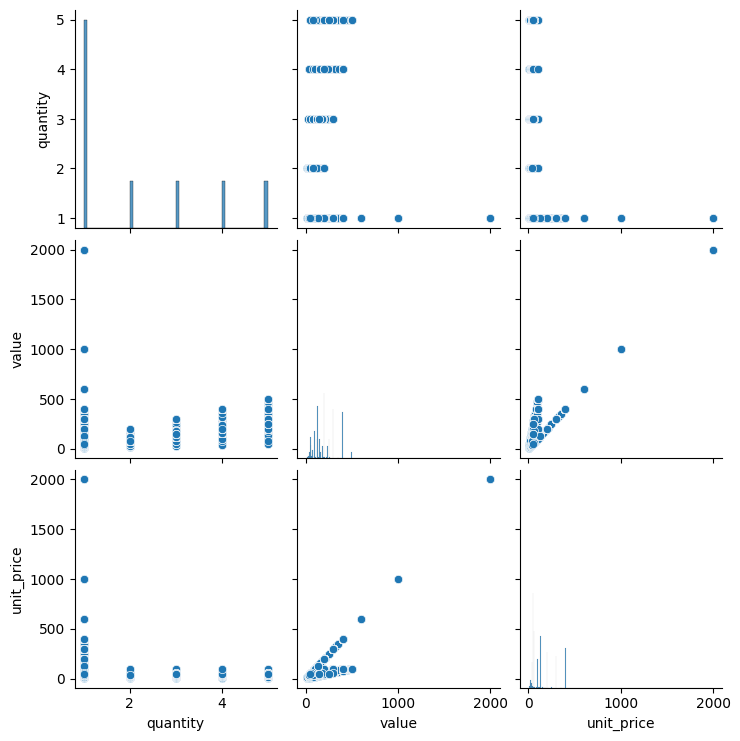

In [ ]:
# Pairplot of quantity, value and unit price
order_items_pd = order_items_df.toPandas()
sns.pairplot(order_items_pd[['quantity', 'value', 'unit_price']])

In [ ]:
departments_rdd_mapped = departments_rdd.map(lambda line: line.split(",")).map(lambda x: Row(
    dept_id=int(x[0]),
    name=x[1]
))

departments_df = departments_rdd_mapped.toDF()
departments_df.show()


+-------+--------+
|dept_id|    name|
+-------+--------+
|      2| Fitness|
|      3|Footwear|
|      4| Apparel|
|      5|    Golf|
|      6|Outdoors|
|      7|Fan Shop|
+-------+--------+



In [ ]:
categories_rdd_mapped = categories_rdd.map(lambda line: line.split(",")).map(lambda x: Row(
    category_id=int(x[0]),
    dept_id=int(x[1]),
    category_name=x[2]
))

categories_df = categories_rdd_mapped.toDF()
categories_df.show()


+-----------+-------+-------------------+
|category_id|dept_id|      category_name|
+-----------+-------+-------------------+
|          1|      2|           Football|
|          2|      2|             Soccer|
|          3|      2|Baseball & Softball|
|          4|      2|         Basketball|
|          5|      2|           Lacrosse|
|          6|      2|   Tennis & Racquet|
|          7|      2|             Hockey|
|          8|      2|        More Sports|
|          9|      3|   Cardio Equipment|
|         10|      3|  Strength Training|
|         11|      3|Fitness Accessories|
|         12|      3|       Boxing & MMA|
|         13|      3|        Electronics|
|         14|      3|     Yoga & Pilates|
|         15|      3|  Training by Sport|
|         16|      3|    As Seen on  TV!|
|         17|      4|             Cleats|
|         18|      4|     Men's Footwear|
|         19|      4|   Women's Footwear|
|         20|      4|     Kids' Footwear|
+-----------+-------+-------------

In [ ]:
products_rdd_mapped = products_rdd.map(lambda line: line.split(",")).map(lambda x: Row(
    p_id=int(x[0]),
    category_id=int(x[1]),
    product_name=x[2],
    link=x[3]
))

products_df = products_rdd_mapped.toDF()
products_df.show()

+----+-----------+--------------------+----+
|p_id|category_id|        product_name|link|
+----+-----------+--------------------+----+
|   1|          2|Quest Q64 10 FT. ...|    |
|   2|          2|Under Armour Men'...|    |
|   3|          2|Under Armour Men'...|    |
|   4|          2|Under Armour Men'...|    |
|   5|          2|Riddell Youth Rev...|    |
|   6|          2|Jordan Men's VI R...|    |
|   7|          2|Schutt Youth Recr...|    |
|   8|          2|Nike Men's Vapor ...|    |
|   9|          2|Nike Adult Vapor ...|    |
|  10|          2|Under Armour Men'...|    |
|  11|          2|Fitness Gear 300 ...|    |
|  12|          2|Under Armour Men'...|    |
|  13|          2|Under Armour Men'...|    |
|  14|          2|Quik Shade Summit...|    |
|  15|          2|Under Armour Kids...|    |
|  16|          2|Riddell Youth 360...|    |
|  17|          2|Under Armour Men'...|    |
|  18|          2|Reebok Men's Full...|    |
|  19|          2|Nike Men's Finger...|    |
|  20|    

Performing joins to check inter-workability

In [ ]:
#join on order_id
orders_order_items_joined_df = orders_df.join(order_items_df, orders_df.order_id == order_items_df.order_id, "inner")

orders_order_items_joined_df.show()


+--------+--------------------+-------+---------------+----+--------+-------+--------+------+----------+
|order_id|           timestamp|  value|         status|  id|order_id|cust_id|quantity| value|unit_price|
+--------+--------------------+-------+---------------+----+--------+-------+--------+------+----------+
|      29|2013-07-25 00:00:...|  196.0|     PROCESSING|  87|      29|   1004|       1|399.98|    399.98|
|      29|2013-07-25 00:00:...|  196.0|     PROCESSING|  86|      29|    403|       1|129.99|    129.99|
|      29|2013-07-25 00:00:...|  196.0|     PROCESSING|  85|      29|    403|       1|129.99|    129.99|
|      29|2013-07-25 00:00:...|  196.0|     PROCESSING|  84|      29|   1014|       5| 249.9|     49.98|
|      29|2013-07-25 00:00:...|  196.0|     PROCESSING|  83|      29|   1073|       1|199.99|    199.99|
|     474|2013-07-27 00:00:...| 8349.0|PENDING_PAYMENT|1165|     474|   1014|       4|199.92|     49.98|
|     474|2013-07-27 00:00:...| 8349.0|PENDING_PAYMENT|

In [ ]:
orders_df.select('order_id').count()

25831125

In [ ]:
#Joining order_items and Products
products_order_items_joined_df = products_df.join(order_items_df, products_df.p_id == order_items_df.id, "inner")

products_order_items_joined_df.show()

+----+-----------+--------------------+----+----+--------+-------+--------+------+----------+
|p_id|category_id|        product_name|link|  id|order_id|cust_id|quantity| value|unit_price|
+----+-----------+--------------------+----+----+--------+-------+--------+------+----------+
|  26|          3|Nike Men's USA Wh...|    |  26|      10|    403|       1|129.99|    129.99|
|  29|          3|Nike Men's USA Aw...|    |  29|      11|    365|       1| 59.99|     59.99|
| 474|         21|Nike Hyper Elite ...|    | 474|     194|    627|       3|119.97|     39.99|
| 964|         44|Coleman River Gor...|    | 964|     388|    627|       3|119.97|     39.99|
|  65|          4|Quik Shade Summit...|    |  65|      21|    276|       4|127.96|     31.99|
| 191|          9|Nike Men's Free 5...|    | 191|      77|    191|       1| 99.99|     99.99|
| 418|         19|Under Armour Men'...|    | 418|     172|    365|       1| 59.99|     59.99|
| 541|         25|adidas Brazuca 20...|    | 541|     222|  

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import functions as F
from pyspark.sql.functions import col

In [ ]:
# Basic EDA for each DataFrame - stats and null values

# Customers DataFrame
print("Customers DataFrame:")
customers_df.describe().show()
customers_df.select([F.count(F.when(F.isnull(c), c)).alias(c) for c in customers_df.columns]).show()

# Orders DataFrame
print("Orders DataFrame:")
orders_df.describe().show()
orders_df.select([F.count(F.when(F.isnull(c), c)).alias(c) for c in orders_df.columns]).show()

# Order Items DataFrame
print("Order Items DataFrame:")
order_items_df.describe().show()
order_items_df.select([F.count(F.when(F.isnull(c), c)).alias(c) for c in order_items_df.columns]).show()

# Departments DataFrame
print("Departments DataFrame:")
departments_df.describe().show()
departments_df.select([F.count(F.when(F.isnull(c), c)).alias(c) for c in departments_df.columns]).show()

# Categories DataFrame
print("Categories DataFrame:")
categories_df.describe().show()
categories_df.select([F.count(F.when(F.isnull(c), c)).alias(c) for c in categories_df.columns]).show()

# Products DataFrame
print("Products DataFrame:")
products_df.describe().show()
products_df.select([F.count(F.when(F.isnull(c), c)).alias(c) for c in products_df.columns]).show()

Customers DataFrame:
+-------+------------------+-------+------+---------+---------+--------------------+----------+-----+------------------+
|summary|           cust_id|  fname| lname|unknown_1|unknown_2|             address|      city|state|             value|
+-------+------------------+-------+------+---------+---------+--------------------+----------+-----+------------------+
|  count|             12435|  12435| 12435|    12435|    12435|               12435|     12435|12435|             12435|
|   mean|            6218.0|   NULL|  NULL|     NULL|     NULL|                NULL|      NULL| NULL|36043.661680739846|
| stddev|3589.8196333520714|   NULL|  NULL|     NULL|     NULL|                NULL|      NULL| NULL| 37623.00199497026|
|    min|                 1|  Aaron|Abbott|XXXXXXXXX|XXXXXXXXX|"10 Crystal River...| Aguadilla|   AL|             603.0|
|    max|             12435|Zachary|Zuniga|XXXXXXXXX|XXXXXXXXX|9995 Tawny Embers...|Zanesville|   WV|           99205.0|
+-------+--

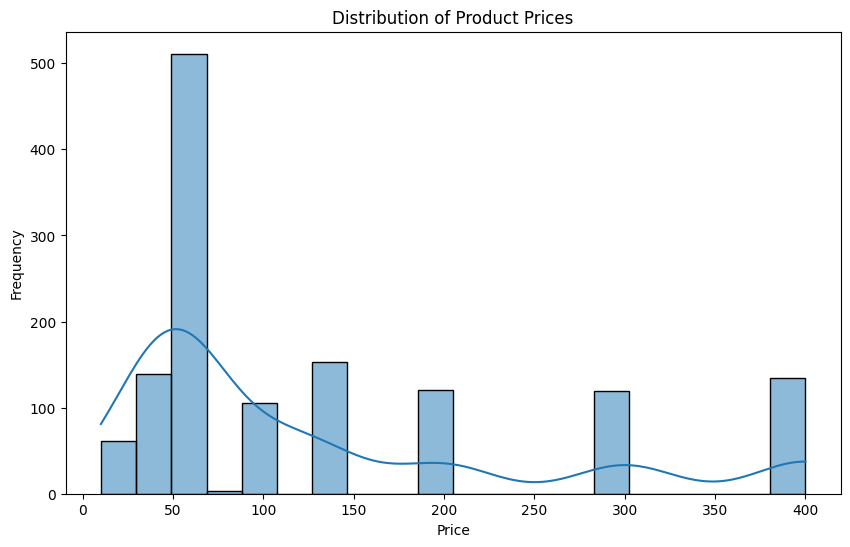

/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


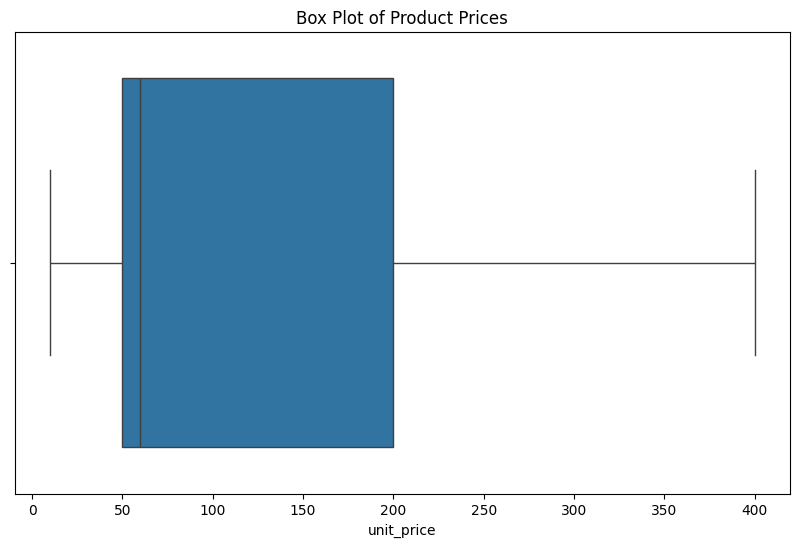

In [ ]:
#Analysing distribution of product Prices
products_joined_pd = products_order_items_joined_df.toPandas()

plt.figure(figsize=(10,6))
sns.histplot(products_joined_pd['unit_price'], bins=20, kde=True)
plt.title('Distribution of Product Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

# Box plot to detect outliers in price
plt.figure(figsize=(10,6))
sns.boxplot(x=products_joined_pd['unit_price'])
plt.title('Box Plot of Product Prices')
plt.show()


<ipython-input-22-c88e926649e6>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="total_value", y="state", data=top_10_states_pd, palette="viridis")
/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grou

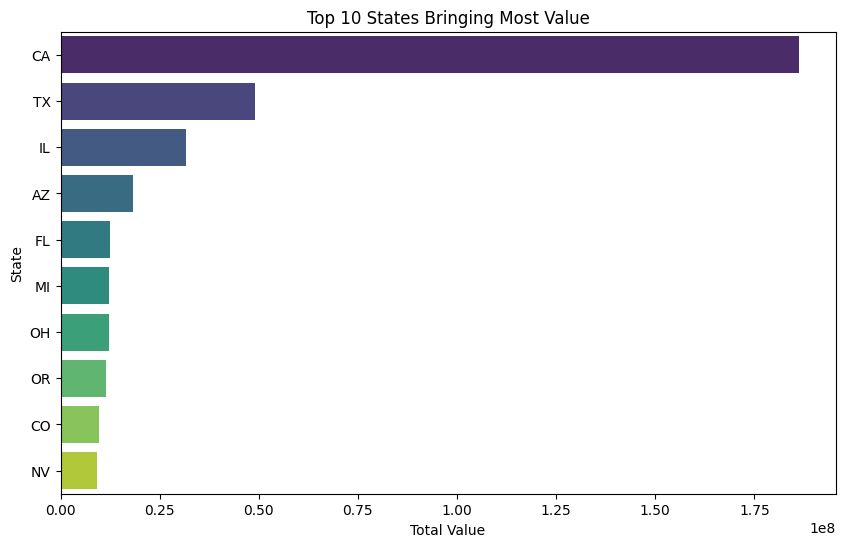

In [ ]:
# Value brought by state
state_value_df = customers_df.groupBy("state").agg(F.sum("value").alias("total_value"))

top_10_states_df = state_value_df.orderBy(F.desc("total_value")).limit(10)
top_10_states_pd = top_10_states_df.toPandas()

# Plot a bar chart
plt.figure(figsize=(10,6))
sns.barplot(x="total_value", y="state", data=top_10_states_pd, palette="viridis")
plt.title("Top 10 States Bringing Most Value")
plt.xlabel("Total Value")
plt.ylabel("State")
plt.show()


In [ ]:
from pyspark.sql.functions import year,max,month

# Extract the year from the timestamp column
orders_df_timeseparated = orders_df.withColumn("year", year(orders_df.timestamp))
orders_df_timeseparated = orders_df_timeseparated.withColumn("month", month(orders_df_timeseparated.timestamp))

orders_df_timeseparated.select(max("year").alias("max_year")).show()

+--------+
|max_year|
+--------+
|    2014|
+--------+



Since we have only 2013 and 2014, we can analyse order frequency by months

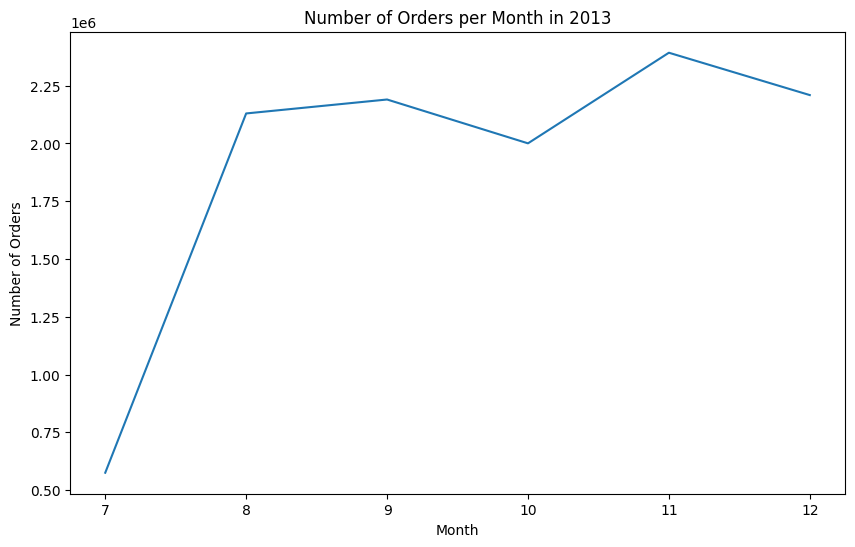

In [ ]:
#Orders by month in 2013
orders_2013_df = orders_df_timeseparated.filter(orders_df_timeseparated.year == 2013)
monthly_order_counts = orders_2013_df.groupBy("month").count().orderBy("month")
monthly_order_counts_pd = monthly_order_counts.toPandas()

plt.figure(figsize=(10, 6))
sns.lineplot(x="month", y="count", data=monthly_order_counts_pd)
plt.title("Number of Orders per Month in 2013")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.show()


In [ ]:
# Sales by Category

# Join products --> order_items --> categories
sales_by_category_df = products_df.join(order_items_df, products_df.p_id == order_items_df.id, "inner") \
    .join(categories_df, products_df.category_id == categories_df.category_id, "inner")

sales_by_category_df = sales_by_category_df.groupBy("category_name") \
    .agg(F.round(F.sum("value"), 2).alias("total_sales"))

top_5_categories_df = sales_by_category_df.orderBy(F.desc("total_sales")).limit(5)
top_5_categories_df.show()


+----------------+-----------+
|   category_name|total_sales|
+----------------+-----------+
|     Accessories|   13458.14|
|Kids' Golf Clubs|   10094.89|
|        Trade-In|    10077.1|
|     Electronics|    9142.01|
|  Featured Shops|     6101.5|
+----------------+-----------+



In [ ]:
# Analysing relationship between departments and price. Showing categories and average ordered units by department

# Join departments-->categories-->products-->order_items
dept_category_order_items_df = departments_df.join(categories_df, departments_df.dept_id == categories_df.dept_id, "inner") \
    .join(products_order_items_joined_df, categories_df.category_id == products_order_items_joined_df.category_id, "inner")

# Calculate average price by department
avg_price_by_dept_df = dept_category_order_items_df.groupBy("name") \
    .agg(F.round(F.avg("unit_price"), 2).alias("avg_price"))

avg_price_by_dept_df.show()

# Calculate average ordered units by department and category
avg_units_by_dept_category_df = dept_category_order_items_df.groupBy("name", "category_name") \
    .agg(F.round(F.avg("quantity"), 2).alias("avg_ordered_units"))

avg_units_by_dept_category_df.show()

+--------+---------+
|    name|avg_price|
+--------+---------+
|    Golf|   114.68|
| Apparel|   141.51|
|Outdoors|   130.88|
| Fitness|    137.6|
|Footwear|   120.54|
|Fan Shop|   129.93|
+--------+---------+

+--------+-------------------+-----------------+
|    name|      category_name|avg_ordered_units|
+--------+-------------------+-----------------+
| Fitness|             Hockey|             1.71|
|Footwear|  Training by Sport|             2.38|
| Apparel|     Featured Shops|             1.83|
|Outdoors|   Kids' Golf Clubs|             2.29|
| Fitness|   Tennis & Racquet|             2.33|
|Footwear|Fitness Accessories|             1.92|
| Apparel|   Women's Footwear|              2.0|
| Fitness|           Lacrosse|             1.75|
|Fan Shop| Hunting & Shooting|             2.58|
|Outdoors|        Golf Gloves|             2.42|
| Fitness|         Basketball|              2.5|
|Outdoors|  Golf Bags & Carts|             2.13|
| Fitness|        More Sports|             1.75|
|Outd

In [ ]:
# Join Products and Categories
products_categories_df = products_df.join(categories_df, products_df["category_id"] == categories_df["category_id"], "inner")
products_categories_df.show()

+----+-----------+--------------------+----+-----------+-------+--------------+
|p_id|category_id|        product_name|link|category_id|dept_id| category_name|
+----+-----------+--------------------+----+-----------+-------+--------------+
| 572|         26|TYR Boys' Team Di...|    |         26|      5|Girls' Apparel|
| 571|         26|TYR Boys' Venom B...|    |         26|      5|Girls' Apparel|
| 570|         26|adidas Men's Germ...|    |         26|      5|Girls' Apparel|
| 569|         26|adidas Men's Germ...|    |         26|      5|Girls' Apparel|
| 568|         26|adidas Youth Germ...|    |         26|      5|Girls' Apparel|
| 567|         26|adidas Men's Germ...|    |         26|      5|Girls' Apparel|
| 566|         26|adidas Men's Germ...|    |         26|      5|Girls' Apparel|
| 565|         26|adidas Youth Germ...|    |         26|      5|Girls' Apparel|
| 564|         26|Nike Men's Deutsc...|    |         26|      5|Girls' Apparel|
| 563|         26|adidas Men's Germ...| 

In [ ]:
# Listing all categories of products sold by each department

dept_categories_df = departments_df.join(categories_df, departments_df.dept_id == categories_df.dept_id, "inner")

dept_categories_df = dept_categories_df.select("name", "category_name")
dept_categories_df.show()

+--------+-------------------+
|    name|      category_name|
+--------+-------------------+
| Fitness|           Football|
| Fitness|             Soccer|
| Fitness|Baseball & Softball|
| Fitness|         Basketball|
| Fitness|           Lacrosse|
| Fitness|   Tennis & Racquet|
| Fitness|             Hockey|
| Fitness|        More Sports|
|Footwear|   Cardio Equipment|
|Footwear|  Strength Training|
|Footwear|Fitness Accessories|
|Footwear|       Boxing & MMA|
|Footwear|        Electronics|
|Footwear|     Yoga & Pilates|
|Footwear|  Training by Sport|
|Footwear|    As Seen on  TV!|
| Apparel|             Cleats|
| Apparel|     Men's Footwear|
| Apparel|   Women's Footwear|
| Apparel|     Kids' Footwear|
+--------+-------------------+
only showing top 20 rows



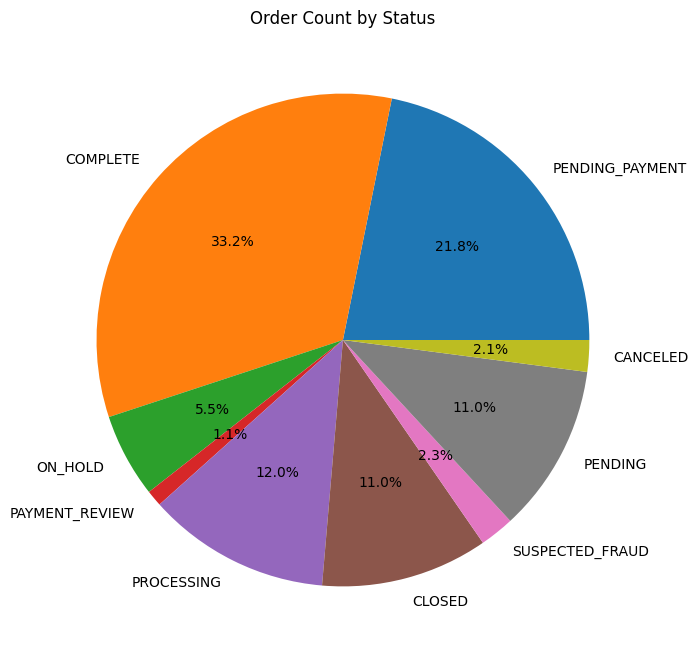

In [ ]:
# Distribution of orders by status

order_status_counts = orders_df.groupBy("status").count().toPandas()

plt.figure(figsize=(8, 8))
plt.pie(order_status_counts["count"], labels=order_status_counts["status"], autopct="%1.1f%%")
plt.title("Order Count by Status")
plt.show()

In [ ]:
# Average order value by customer
avg_order_value_by_customer_df = order_items_df.groupBy("cust_id") \
    .agg(F.round(F.avg("value"), 2).alias("avg_order_value"))

avg_order_value_by_customer_df.show()

+-------+---------------+
|cust_id|avg_order_value|
+-------+---------------+
|    191|         301.39|
|    278|         130.63|
|    926|          49.24|
|    502|         149.65|
|    564|          91.31|
|    823|         154.27|
|    828|          93.49|
|   1073|         199.99|
|    116|         135.93|
|    642|          91.58|
|    703|          58.52|
|    365|         180.34|
|    897|          73.19|
|    825|          100.2|
|    276|          94.53|
|    977|          92.66|
|    235|           99.0|
|    818|         142.32|
|    403|         129.99|
|    797|          53.67|
+-------+---------------+
only showing top 20 rows



In [ ]:
# Customers and their order frequency
customer_order_frequency_df = order_items_df.groupBy("cust_id").count() \
    .withColumnRenamed("count", "order_frequency")

customer_order_frequency_df.show()

+-------+---------------+
|cust_id|order_frequency|
+-------+---------------+
|    191|          12169|
|    278|            280|
|    926|            302|
|    502|          21035|
|    564|            298|
|    823|            306|
|    828|            310|
|   1073|          15500|
|    116|            328|
|    642|            304|
|    703|            303|
|    365|          24515|
|    897|            281|
|    825|            257|
|    276|            311|
|    977|            323|
|    235|            299|
|    818|            291|
|    403|          22246|
|    797|            298|
+-------+---------------+
only showing top 20 rows



In [ ]:
# Identify customers with highest total purchase value
customer_total_purchase_df = order_items_df.groupBy("cust_id") \
    .agg(F.sum("value").alias("total_purchase_value")) \
    .orderBy(F.desc("total_purchase_value"))

customer_total_purchase_df.show()

+-------+--------------------+
|cust_id|total_purchase_value|
+-------+--------------------+
|   1004|   6929653.499999708|
|    365|   4421143.019999638|
|    957|   4118425.419999785|
|    191|  3667633.1999997487|
|    502|           3147800.0|
|   1073|   3099844.999999871|
|    403|  2891757.5399998166|
|   1014|  2888993.9399996493|
|    627|   1269082.649999932|
|    565|             67830.0|
|    728|             61490.0|
|     44|   56330.61000000003|
|    823|  47206.920000000006|
|    249|   46559.58999999997|
|    116|   44585.09000000002|
|    821|  44243.490000000005|
|    818|            41415.37|
|    822|   38391.99999999997|
|    278|   36576.86999999999|
|    572|   35191.19999999998|
+-------+--------------------+
only showing top 20 rows



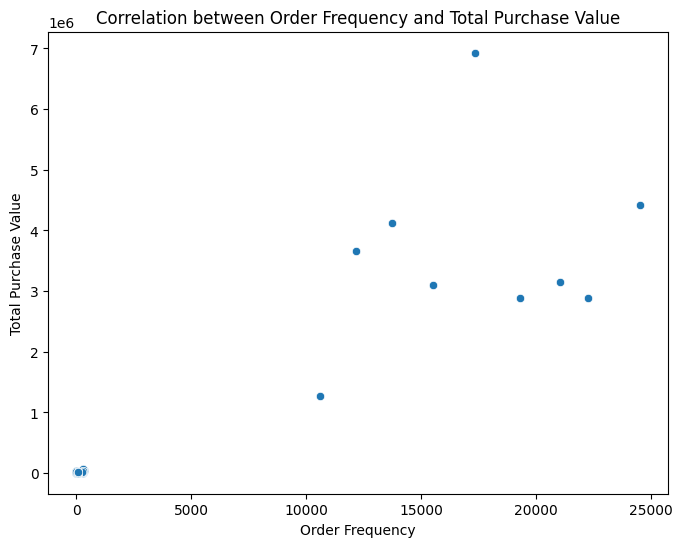

In [ ]:
# Analyze the correlation between customer value and order frequency
customer_value_frequency_df = customer_total_purchase_df.join(customer_order_frequency_df, "cust_id")

customer_value_frequency_pd = customer_value_frequency_df.toPandas()

plt.figure(figsize=(8, 6))
sns.scatterplot(x="order_frequency", y="total_purchase_value", data=customer_value_frequency_pd)
plt.title("Correlation between Order Frequency and Total Purchase Value")
plt.xlabel("Order Frequency")
plt.ylabel("Total Purchase Value")
plt.show()

In [ ]:
# Top 10 products with the highest total sales
top_10_products_sales_df = products_order_items_joined_df.groupBy("product_name") \
    .agg(F.sum("value").alias("total_sales")) \
    .orderBy(F.desc("total_sales")) \
    .limit(10)

top_10_products_sales_df.show()

+--------------------+------------------+
|        product_name|       total_sales|
+--------------------+------------------+
|Under Armour Men'...| 4479.489999999999|
|   Nike+ Fuelband SE|           2889.67|
|Fitbit Flex Wirel...|           2669.76|
|"Nike Women's Pro...|2469.8500000000004|
|Nike Kids' Grade ...|           2419.84|
|Kijaro Dual Lock ...|           2219.75|
|Nike Women's Temp...|           2187.71|
|Nike Women's Pro ...|           2112.75|
|Under Armour Men'...|2009.8500000000001|
|Quest Q64 10 FT. ...|2009.7700000000002|
+--------------------+------------------+



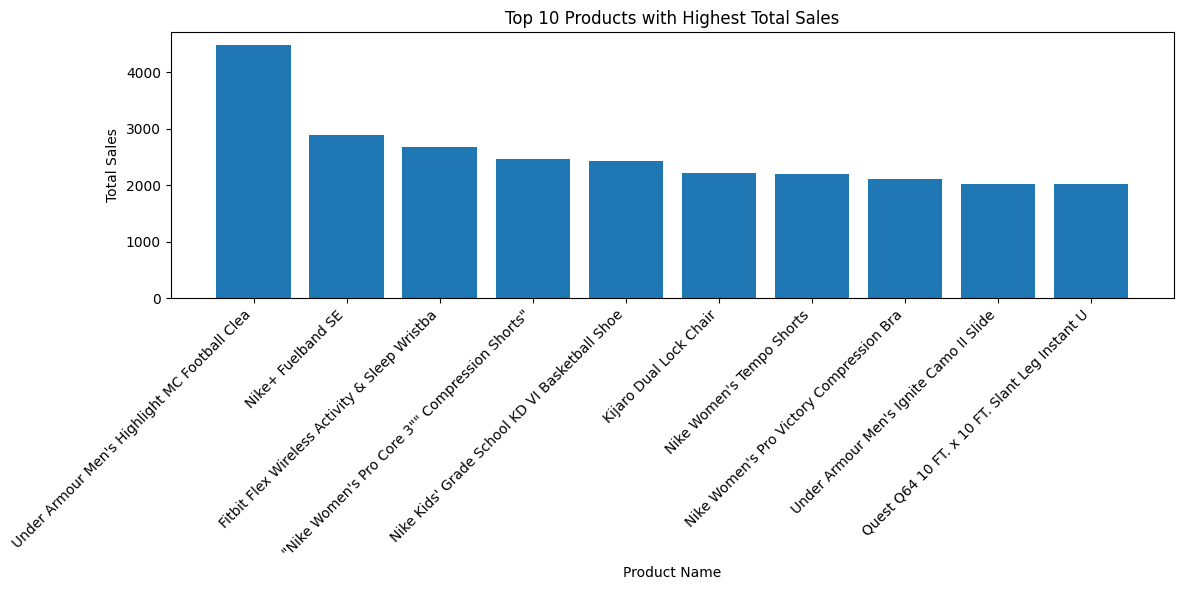

In [ ]:
top_10_products_sales_pd = top_10_products_sales_df.toPandas()

# Create a bar chart
plt.figure(figsize=(12, 6))
plt.bar(top_10_products_sales_pd["product_name"], top_10_products_sales_pd["total_sales"])
plt.xlabel("Product Name")
plt.ylabel("Total Sales")
plt.title("Top 10 Products with Highest Total Sales")
plt.xticks(rotation=45, ha = 'right')
plt.tight_layout()
plt.show()

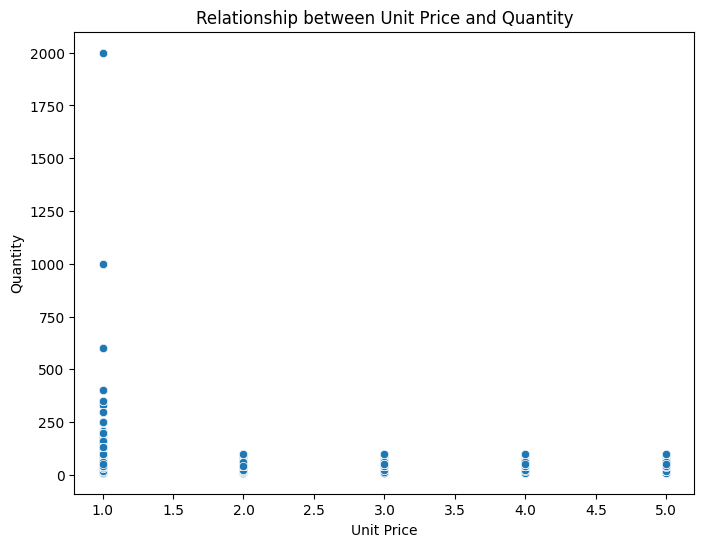

In [ ]:
order_items_pd = order_items_df.toPandas()
plt.figure(figsize=(8, 6))
sns.scatterplot(x="quantity", y="unit_price", data= order_items_pd)
plt.title("Relationship between Unit Price and Quantity")
plt.xlabel("Quantity")
plt.ylabel("Unit_Price")
plt.show()

On exploring the relationship between unit_price and quantity we see a hugehr amount of cheaper items while a lower amount of rather expensive items being purchased, with almost equal distribution of quantity among those purchase values.

In [ ]:
# Top 5 best selling products in hockey, soccer, football and basketball
hockey_products = products_categories_df.filter(products_categories_df.category_name.contains("Hockey"))
soccer_products = products_categories_df.filter(products_categories_df.category_name.contains("Soccer"))
football_products = products_categories_df.filter(products_categories_df.category_name.contains("Football"))
basketball_products = products_categories_df.filter(products_categories_df.category_name.contains("Basketball"))

def get_top_selling_products(products_df, top_n=5):

  top_products_df = products_df.join(order_items_df, products_df.p_id == order_items_df.id, "inner") \
      .groupBy("product_name") \
      .agg(F.sum("quantity").alias("total_quantity_sold")) \
      .orderBy(F.desc("total_quantity_sold")) \
      .limit(top_n)
  return top_products_df

# Get top 5 best-selling products for each category
top_hockey_products = get_top_selling_products(hockey_products)
top_soccer_products = get_top_selling_products(soccer_products)
top_football_products = get_top_selling_products(football_products)
top_basketball_products = get_top_selling_products(basketball_products)


print("Top 5 Best Selling Hockey Products:")
top_hockey_products.show()

print("Top 5 Best Selling Soccer Products:")
top_soccer_products.show()

print("Top 5 Best Selling Football Products:")
top_football_products.show()

print("Top 5 Best Selling Basketball Products:")
top_basketball_products.show()


Top 5 Best Selling Hockey Products:
+--------------------+-------------------+
|        product_name|total_quantity_sold|
+--------------------+-------------------+
|Kijaro Dual Lock ...|                  5|
|Nike Hoops Elite ...|                  4|
|Nike Elite Crew B...|                  4|
|Quest Q100 10' X ...|                  3|
|Quest 12' x 12' D...|                  3|
+--------------------+-------------------+

Top 5 Best Selling Soccer Products:
+--------------------+-------------------+
|        product_name|total_quantity_sold|
+--------------------+-------------------+
|Under Armour Men'...|                 10|
|Under Armour Men'...|                  7|
|Jordan Men's VI R...|                  5|
|"adidas Men's New...|                  5|
|Reebok Men's Full...|                  5|
+--------------------+-------------------+

Top 5 Best Selling Football Products:
+------------+-------------------+
|product_name|total_quantity_sold|
+------------+-------------------+
+--------

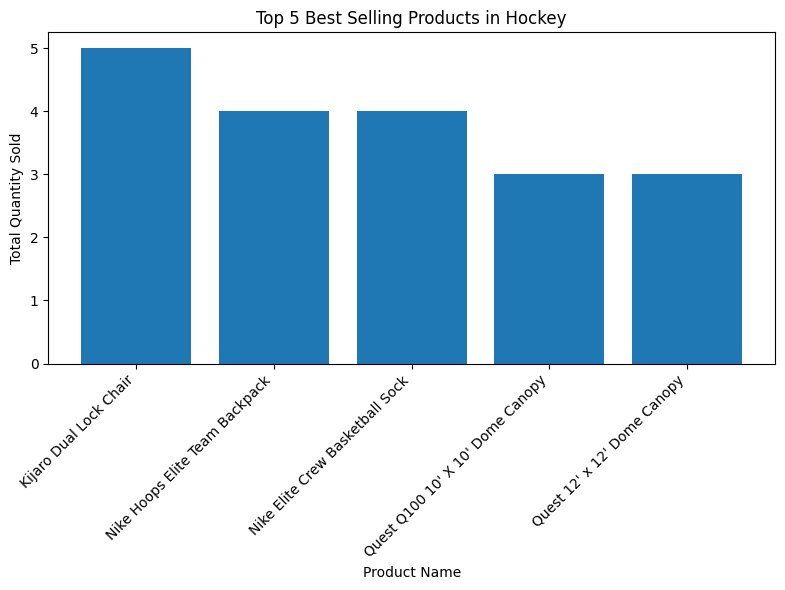

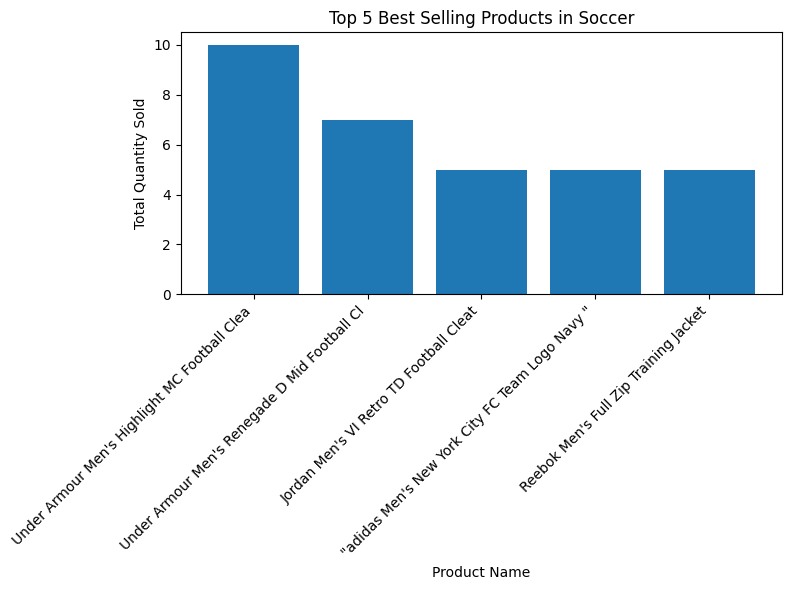

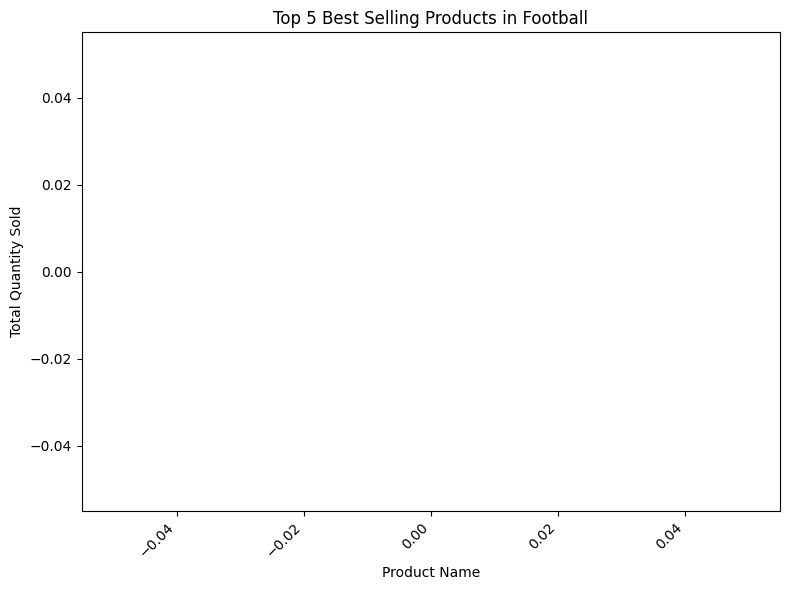

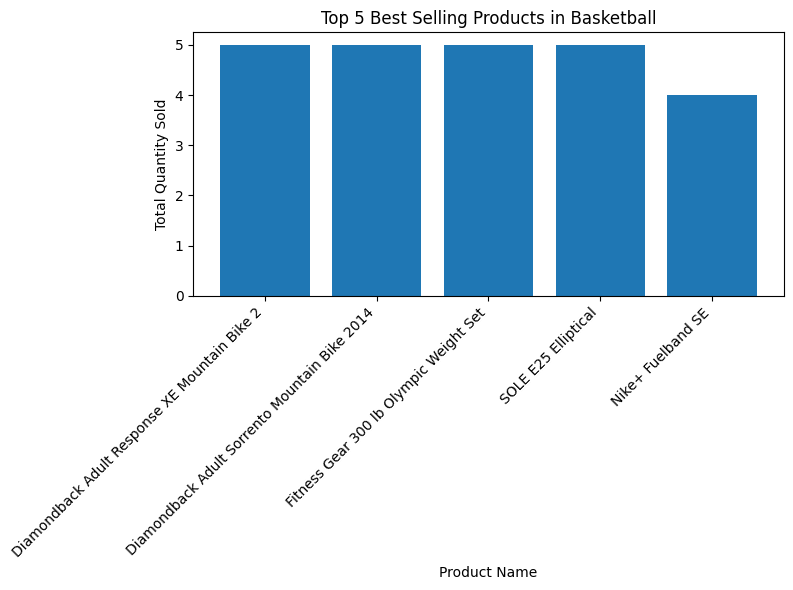

In [ ]:
# Visualizing Results
def visualize_top_products(products_df, category_name):
  top_products_df = get_top_selling_products(products_df)
  top_products_pd = top_products_df.toPandas()

  plt.figure(figsize=(8, 6))
  plt.bar(top_products_pd["product_name"], top_products_pd["total_quantity_sold"])
  plt.xlabel("Product Name")
  plt.ylabel("Total Quantity Sold")
  plt.title(f"Top 5 Best Selling Products in {category_name}")
  plt.xticks(rotation=45, ha='right')
  plt.tight_layout()
  plt.show()

visualize_top_products(hockey_products, "Hockey")
visualize_top_products(soccer_products, "Soccer")
visualize_top_products(football_products, "Football")
visualize_top_products(basketball_products, "Basketball")


Correlation Plot to asses the relationship between value, price and qty.

               value  unit_price  quantity
value       1.000000    0.702009  0.161593
unit_price  0.702009    1.000000 -0.532411
quantity    0.161593   -0.532411  1.000000


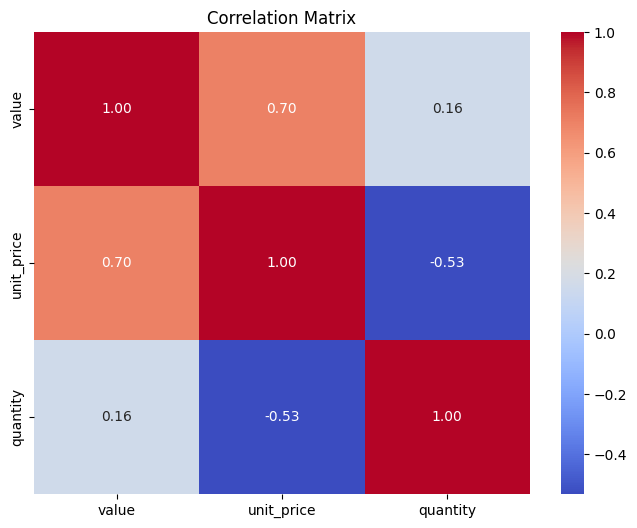

In [ ]:
correlation_matrix = order_items_pd[['value', 'unit_price', 'quantity']].corr()

# Display the correlation matrix
print(correlation_matrix)

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

## **Department Performance Analysis**

Cleaning Customers_df

In [ ]:
#dropping irrelevant columns
customers_df_new = customers_df.drop("unknown_1", "unknown_2")

In [ ]:
from pyspark.sql.functions import concat, lit
#combining name columns
customers_df_new = customers_df_new.withColumn("full_name", concat(col("fname"), lit(" "), col("lname")))
customers_df_new.show()

+-------+-----------+---------+--------------------+-------------+-----+-------+------------------+
|cust_id|      fname|    lname|             address|         city|state|  value|         full_name|
+-------+-----------+---------+--------------------+-------------+-----+-------+------------------+
|      1|    Richard|Hernandez|  6303 Heather Plaza|  Brownsville|   TX|78521.0| Richard Hernandez|
|      2|       Mary|  Barrett|9526 Noble Embers...|    Littleton|   CO|80126.0|      Mary Barrett|
|      3|        Ann|    Smith|3422 Blue Pioneer...|       Caguas|   PR|  725.0|         Ann Smith|
|      4|       Mary|    Jones|  8324 Little Common|   San Marcos|   CA|92069.0|        Mary Jones|
|      5|     Robert|   Hudson|"10 Crystal River...|       Caguas|   PR|  725.0|     Robert Hudson|
|      6|       Mary|    Smith|3151 Sleepy Quail...|      Passaic|   NJ| 7055.0|        Mary Smith|
|      7|    Melissa|   Wilcox|9453 High Concession|       Caguas|   PR|  725.0|    Melissa Wilcox|


In [ ]:
# Dropping old name columns and renaming value to cust_value to avoid
#confusion when joining.

customers_df_new = customers_df_new.drop("fname", "lname")
customers_df_new = customers_df_new.withColumnRenamed("value", "cust_value")
customers_df_new.show()

+-------+--------------------+-------------+-----+----------+------------------+
|cust_id|             address|         city|state|cust_value|         full_name|
+-------+--------------------+-------------+-----+----------+------------------+
|      1|  6303 Heather Plaza|  Brownsville|   TX|   78521.0| Richard Hernandez|
|      2|9526 Noble Embers...|    Littleton|   CO|   80126.0|      Mary Barrett|
|      3|3422 Blue Pioneer...|       Caguas|   PR|     725.0|         Ann Smith|
|      4|  8324 Little Common|   San Marcos|   CA|   92069.0|        Mary Jones|
|      5|"10 Crystal River...|       Caguas|   PR|     725.0|     Robert Hudson|
|      6|3151 Sleepy Quail...|      Passaic|   NJ|    7055.0|        Mary Smith|
|      7|9453 High Concession|       Caguas|   PR|     725.0|    Melissa Wilcox|
|      8|3047 Foggy Forest...|     Lawrence|   MA|    1841.0|       Megan Smith|
|      9| 3616 Quaking Street|       Caguas|   PR|     725.0|        Mary Perez|
|     10|8598 Harvest Beac..

Cleaning orders_df

In [ ]:
#Extracting eyar and month from orders_df
from pyspark.sql.functions import year, month

orders_df_new = orders_df.withColumn("year", year("timestamp")) \
                                     .withColumn("month", month("timestamp"))

orders_df_new.show()

+--------+--------------------+-------+---------------+----+-----+
|order_id|           timestamp|  value|         status|year|month|
+--------+--------------------+-------+---------------+----+-----+
|       1|2013-07-25 00:00:...|11599.0|         CLOSED|2013|    7|
|       2|2013-07-25 00:00:...|  256.0|PENDING_PAYMENT|2013|    7|
|       3|2013-07-25 00:00:...|12111.0|       COMPLETE|2013|    7|
|       4|2013-07-25 00:00:...| 8827.0|         CLOSED|2013|    7|
|       5|2013-07-25 00:00:...|11318.0|       COMPLETE|2013|    7|
|       6|2013-07-25 00:00:...| 7130.0|       COMPLETE|2013|    7|
|       7|2013-07-25 00:00:...| 4530.0|       COMPLETE|2013|    7|
|       8|2013-07-25 00:00:...| 2911.0|     PROCESSING|2013|    7|
|       9|2013-07-25 00:00:...| 5657.0|PENDING_PAYMENT|2013|    7|
|      10|2013-07-25 00:00:...| 5648.0|PENDING_PAYMENT|2013|    7|
|      11|2013-07-25 00:00:...|  918.0| PAYMENT_REVIEW|2013|    7|
|      12|2013-07-25 00:00:...| 1837.0|         CLOSED|2013|  

In [ ]:
#Dropping timestamp column and renaming value to order_value
orders_df_new = orders_df_new.drop("timestamp")
orders_df_new = orders_df_new.withColumnRenamed("value", "order_value")
orders_df_new.show()

+--------+-----------+---------------+----+-----+
|order_id|order_value|         status|year|month|
+--------+-----------+---------------+----+-----+
|       1|    11599.0|         CLOSED|2013|    7|
|       2|      256.0|PENDING_PAYMENT|2013|    7|
|       3|    12111.0|       COMPLETE|2013|    7|
|       4|     8827.0|         CLOSED|2013|    7|
|       5|    11318.0|       COMPLETE|2013|    7|
|       6|     7130.0|       COMPLETE|2013|    7|
|       7|     4530.0|       COMPLETE|2013|    7|
|       8|     2911.0|     PROCESSING|2013|    7|
|       9|     5657.0|PENDING_PAYMENT|2013|    7|
|      10|     5648.0|PENDING_PAYMENT|2013|    7|
|      11|      918.0| PAYMENT_REVIEW|2013|    7|
|      12|     1837.0|         CLOSED|2013|    7|
|      13|     9149.0|PENDING_PAYMENT|2013|    7|
|      14|     9842.0|     PROCESSING|2013|    7|
|      15|     2568.0|       COMPLETE|2013|    7|
|      16|     7276.0|PENDING_PAYMENT|2013|    7|
|      17|     2667.0|       COMPLETE|2013|    7|


Cleaning order_items_df

In [ ]:
#Renaming columns for imputing later on
order_items_df_new = order_items_df.withColumnRenamed("value", "item_value")
order_items_df_new = order_items_df_new.withColumnRenamed("id", "p_id")
order_items_df_new = order_items_df_new.withColumnRenamed("order_id", "o_id")
order_items_df_new = order_items_df_new.withColumnRenamed("cust_id", "c_id")
order_items_df_new.show()

+----+----+----+--------+----------+----------+
|p_id|o_id|c_id|quantity|item_value|unit_price|
+----+----+----+--------+----------+----------+
|   1|   1| 957|       1|    299.98|    299.98|
|   2|   2|1073|       1|    199.99|    199.99|
|   3|   2| 502|       5|     250.0|      50.0|
|   4|   2| 403|       1|    129.99|    129.99|
|   5|   4| 897|       2|     49.98|     24.99|
|   6|   4| 365|       5|    299.95|     59.99|
|   7|   4| 502|       3|     150.0|      50.0|
|   8|   4|1014|       4|    199.92|     49.98|
|   9|   5| 957|       1|    299.98|    299.98|
|  10|   5| 365|       5|    299.95|     59.99|
|  11|   5|1014|       2|     99.96|     49.98|
|  12|   5| 957|       1|    299.98|    299.98|
|  13|   5| 403|       1|    129.99|    129.99|
|  14|   7|1073|       1|    199.99|    199.99|
|  15|   7| 957|       1|    299.98|    299.98|
|  16|   7| 926|       5|     79.95|     15.99|
|  17|   8| 365|       3|    179.97|     59.99|
|  18|   8| 365|       5|    299.95|    

Setting up categories, departments and products as required

In [ ]:
#Renaming columns for imputing later on
categories_df_new = categories_df.withColumnRenamed("dept_id", "d_id")
categories_df_new.show()

+-----------+----+-------------------+
|category_id|d_id|      category_name|
+-----------+----+-------------------+
|          1|   2|           Football|
|          2|   2|             Soccer|
|          3|   2|Baseball & Softball|
|          4|   2|         Basketball|
|          5|   2|           Lacrosse|
|          6|   2|   Tennis & Racquet|
|          7|   2|             Hockey|
|          8|   2|        More Sports|
|          9|   3|   Cardio Equipment|
|         10|   3|  Strength Training|
|         11|   3|Fitness Accessories|
|         12|   3|       Boxing & MMA|
|         13|   3|        Electronics|
|         14|   3|     Yoga & Pilates|
|         15|   3|  Training by Sport|
|         16|   3|    As Seen on  TV!|
|         17|   4|             Cleats|
|         18|   4|     Men's Footwear|
|         19|   4|   Women's Footwear|
|         20|   4|     Kids' Footwear|
+-----------+----+-------------------+
only showing top 20 rows



In [ ]:
#Renamign necessary id columns and dropping link
products_df_new = products_df.withColumnRenamed("category_id", "cat_id")
products_df_new = products_df_new.withColumnRenamed("p_id", "product_id")
products_df_new = products_df_new.drop('link')
products_df_new.show()

+----------+------+--------------------+
|product_id|cat_id|        product_name|
+----------+------+--------------------+
|         1|     2|Quest Q64 10 FT. ...|
|         2|     2|Under Armour Men'...|
|         3|     2|Under Armour Men'...|
|         4|     2|Under Armour Men'...|
|         5|     2|Riddell Youth Rev...|
|         6|     2|Jordan Men's VI R...|
|         7|     2|Schutt Youth Recr...|
|         8|     2|Nike Men's Vapor ...|
|         9|     2|Nike Adult Vapor ...|
|        10|     2|Under Armour Men'...|
|        11|     2|Fitness Gear 300 ...|
|        12|     2|Under Armour Men'...|
|        13|     2|Under Armour Men'...|
|        14|     2|Quik Shade Summit...|
|        15|     2|Under Armour Kids...|
|        16|     2|Riddell Youth 360...|
|        17|     2|Under Armour Men'...|
|        18|     2|Reebok Men's Full...|
|        19|     2|Nike Men's Finger...|
|        20|     2|Under Armour Men'...|
+----------+------+--------------------+
only showing top

In [ ]:
departments_df_new = departments_df.withColumnRenamed("name", "dept_name")
departments_df_new.show()

+-------+---------+
|dept_id|dept_name|
+-------+---------+
|      2|  Fitness|
|      3| Footwear|
|      4|  Apparel|
|      5|     Golf|
|      6| Outdoors|
|      7| Fan Shop|
+-------+---------+



Our dataframes have now been standardized in terms of column requirement and names

In [ ]:
# Join all dataframes using inner joins
sales_raw_df = customers_df_new.join(order_items_df_new, customers_df_new.cust_id == order_items_df_new.c_id, "inner") \
    .join(orders_df_new, order_items_df_new.o_id == orders_df_new.order_id, "inner") \
    .join(products_df_new, order_items_df_new.p_id == products_df_new.product_id, "inner") \
    .join(categories_df_new, products_df_new.cat_id == categories_df_new.category_id, "inner") \
    .join(departments_df_new, categories_df_new.d_id == departments_df_new.dept_id, "inner")

sales_raw_df.show()

+-------+--------------------+--------+-----+----------+------------+----+----+----+--------+----------+----------+--------+-----------+-------+----+-----+----------+------+--------------------+-----------+----+---------------+-------+---------+
|cust_id|             address|    city|state|cust_value|   full_name|p_id|o_id|c_id|quantity|item_value|unit_price|order_id|order_value| status|year|month|product_id|cat_id|        product_name|category_id|d_id|  category_name|dept_id|dept_name|
+-------+--------------------+--------+-----+----------+------------+----+----+----+--------+----------+----------+--------+-----------+-------+----+-----+----------+------+--------------------+-----------+----+---------------+-------+---------+
|    627|4728 Amber Lake T...|Honolulu|   HI|   96822.0|Robert Smith| 516| 212| 627|       4|    159.96|     39.99|     212|     3190.0|PENDING|2013|    7|       516|    24|Callaway X Hot La...|         24|   5|Women's Apparel|      5|     Golf|
|    627|4728 Am

In [ ]:
from pyspark.sql.functions import rand, round

# Generate random customer satisfaction scores between 1 and 5
sales_raw_df = sales_raw_df.withColumn(
    "customer_satisfaction", round(rand() * 4 + 1)
)

sales_raw_df.show()

+-------+--------------------+--------+-----+----------+------------+----+----+----+--------+----------+----------+--------+-----------+-------+----+-----+----------+------+--------------------+-----------+----+---------------+-------+---------+---------------------+
|cust_id|             address|    city|state|cust_value|   full_name|p_id|o_id|c_id|quantity|item_value|unit_price|order_id|order_value| status|year|month|product_id|cat_id|        product_name|category_id|d_id|  category_name|dept_id|dept_name|customer_satisfaction|
+-------+--------------------+--------+-----+----------+------------+----+----+----+--------+----------+----------+--------+-----------+-------+----+-----+----------+------+--------------------+-----------+----+---------------+-------+---------+---------------------+
|    627|4728 Amber Lake T...|Honolulu|   HI|   96822.0|Robert Smith| 516| 212| 627|       4|    159.96|     39.99|     212|     3190.0|PENDING|2013|    7|       516|    24|Callaway X Hot La...|  

In [ ]:
#Imputing unnecessary columns
sales_raw_df = sales_raw_df.drop("c_id", "o_id", "p_id", "cat_id", "d_id")
sales_raw_df.show()

+-------+-----------------+------------+-----+----------+---------------+--------+----------+----------+--------+-----------+--------+----+-----+----------+--------------------+-----------+-------------+-------+---------+---------------------+
|cust_id|          address|        city|state|cust_value|      full_name|quantity|item_value|unit_price|order_id|order_value|  status|year|month|product_id|        product_name|category_id|category_name|dept_id|dept_name|customer_satisfaction|
+-------+-----------------+------------+-----+----------+---------------+--------+----------+----------+--------+-----------+--------+----+-----+----------+--------------------+-----------+-------------+-------+---------+---------------------+
|    926|9117 Rustic Beach|Wilkes Barre|   PA|   18702.0|Ashley Browning|       5|     79.95|     15.99|       7|     4530.0|COMPLETE|2013|    7|        16|Riddell Youth 360...|          2|       Soccer|      2|  Fitness|                  4.0|
|    926|9117 Rustic Bea

In [ ]:
# Get unique department names
department_names = sales_raw_df.select("dept_name").distinct()
department_names.show()

+---------+
|dept_name|
+---------+
|     Golf|
|  Apparel|
| Outdoors|
|  Fitness|
| Footwear|
| Fan Shop|
+---------+



In [ ]:
#Golf sales Dataframe
golf_df = sales_raw_df.filter(sales_raw_df.dept_name == "Golf")
golf_df.show()

#Apparel sales Dataframe
apparel_df = sales_raw_df.filter(sales_raw_df.dept_name == "Apparel")
apparel_df.show()

#Outdoors sales Dataframe
outdoors_df = sales_raw_df.filter(sales_raw_df.dept_name == "Outdoors")
outdoors_df.show()

#Fitness sales Dataframe
fitness_df = sales_raw_df.filter(sales_raw_df.dept_name == "Fitness")
fitness_df.show()

#Footwear sales Dataframe
footwear_df = sales_raw_df.filter(sales_raw_df.dept_name == "Footwear")
footwear_df.show()

#Fan Shop sales Dataframe
fan_shop_df = sales_raw_df.filter(sales_raw_df.dept_name == "Fan Shop")
fan_shop_df.show()

+-------+--------------------+--------+-----+----------+------------+--------+----------+----------+--------+-----------+-------+----+-----+----------+--------------------+-----------+---------------+-------+---------+---------------------+
|cust_id|             address|    city|state|cust_value|   full_name|quantity|item_value|unit_price|order_id|order_value| status|year|month|product_id|        product_name|category_id|  category_name|dept_id|dept_name|customer_satisfaction|
+-------+--------------------+--------+-----+----------+------------+--------+----------+----------+--------+-----------+-------+----+-----+----------+--------------------+-----------+---------------+-------+---------+---------------------+
|    627|4728 Amber Lake T...|Honolulu|   HI|   96822.0|Robert Smith|       4|    159.96|     39.99|     212|     3190.0|PENDING|2013|    7|       516|Callaway X Hot La...|         24|Women's Apparel|      5|     Golf|                  3.0|
|    627|4728 Amber Lake T...|Honolu

Location specific comparison

In [ ]:
# Average order value and quantity ordered for each department for orders where state is NY

# Filter for orders where the state is NY
ny_orders_df = sales_raw_df.filter(sales_raw_df.state == "NY")

department_performance_ny_df = ny_orders_df.groupBy("dept_name") \
    .agg(
        F.round(F.avg("order_value"), 2).alias("avg_order_value"),
        F.round(F.avg("quantity"), 2).alias("avg_quantity_ordered")
    )


department_performance_ny_df.show()

+---------+---------------+--------------------+
|dept_name|avg_order_value|avg_quantity_ordered|
+---------+---------------+--------------------+
|     Golf|        6463.68|                3.04|
|  Apparel|         6739.0|                3.04|
| Outdoors|        5268.26|                2.78|
|  Fitness|        5999.63|                2.85|
| Footwear|        6255.27|                2.85|
| Fan Shop|        5998.38|                2.97|
+---------+---------------+--------------------+



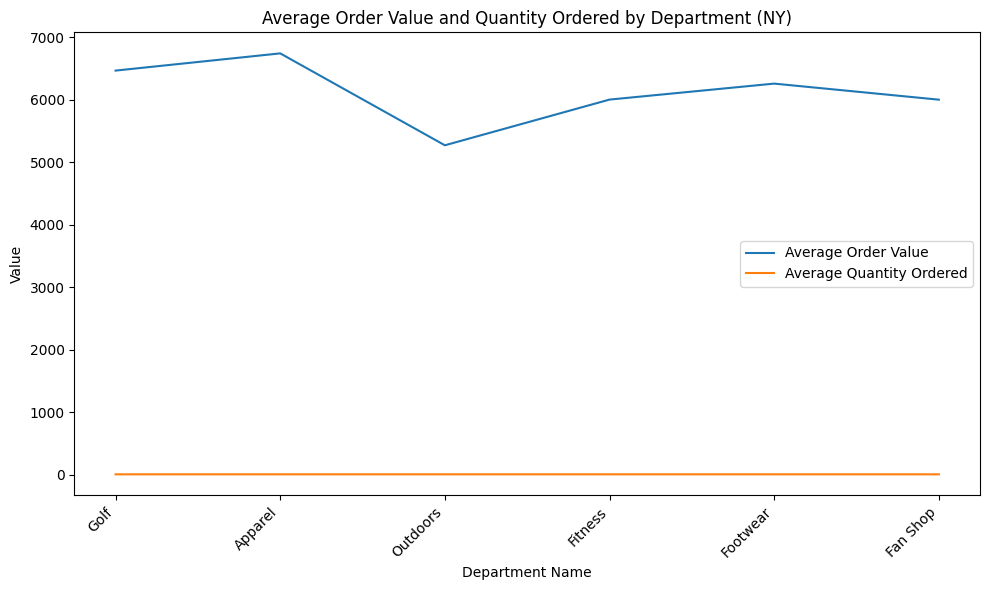

In [ ]:
# Line chart to show avg_order_value and avg_quantity_ordered by department.

department_performance_ny_pd = department_performance_ny_df.toPandas()

plt.figure(figsize=(10, 6))
plt.plot(department_performance_ny_pd["dept_name"], department_performance_ny_pd["avg_order_value"], label="Average Order Value")
plt.plot(department_performance_ny_pd["dept_name"], department_performance_ny_pd["avg_quantity_ordered"], label="Average Quantity Ordered")

plt.xlabel("Department Name")
plt.ylabel("Value")
plt.title("Average Order Value and Quantity Ordered by Department (NY)")
plt.xticks(rotation=45, ha="right")
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
#Calculating metrics for each department

from pyspark.sql.functions import sum, avg, count, countDistinct

def calculate_department_metrics(df):
  """Calculates various metrics for a given department DataFrame."""

  department_metrics_df = df.groupBy("dept_name") \
      .agg(
          sum("item_value").alias("total_revenue"),
          avg("order_value").alias("avg_order_value"),
          countDistinct("order_id").alias("num_orders"),
          avg("unit_price").alias("avg_unit_price"),
          sum("quantity").alias("num_products_sold"),
          countDistinct("cust_id").alias("num_unique_customers"),
          countDistinct("product_name").alias("num_unique_products"),
          countDistinct("category_name").alias("num_unique_categories"),
          avg("customer_satisfaction").alias("avg_customer_satisfaction")
      )

  return department_metrics_df


# Calculate metrics for each department
golf_metrics_df = calculate_department_metrics(golf_df)
apparel_metrics_df = calculate_department_metrics(apparel_df)
outdoors_metrics_df = calculate_department_metrics(outdoors_df)
fitness_metrics_df = calculate_department_metrics(fitness_df)
footwear_metrics_df = calculate_department_metrics(footwear_df)
fan_shop_metrics_df = calculate_department_metrics(fan_shop_df)



print("Golf Department Metrics:")
golf_metrics_df.show()

print("Apparel Department Metrics:")
apparel_metrics_df.show()

print("Outdoors Department Metrics:")
outdoors_metrics_df.show()

print("Fitness Department Metrics:")
fitness_metrics_df.show()

print("Footwear Department Metrics:")
footwear_metrics_df.show()

print("Fan Shop Department Metrics:")
fan_shop_metrics_df.show()


Golf Department Metrics:
+---------+------------------+-----------------+----------+------------------+-----------------+--------------------+-----------------+-------------------+---------------------+-------------------------+
|dept_name|     total_revenue|  avg_order_value|num_orders|    avg_unit_price|num_products_sold|num_unique_customers|total_order_value|num_unique_products|num_unique_categories|avg_customer_satisfaction|
+---------+------------------+-----------------+----------+------------------+-----------------+--------------------+-----------------+-------------------+---------------------+-------------------------+
|     Golf|8227623.7500045495|6898.733333333334|        40|114.68108333342595|           101250|                  19|        3.10443E8|                 69|                    5|        3.011311111111111|
+---------+------------------+-----------------+----------+------------------+-----------------+--------------------+-----------------+-------------------+----

In [ ]:
#Finding the most purchased product in each department
from pyspark.sql.functions import desc

def get_top_product_by_department(df):
  """
  Finds the most bought product in each department.
  """
  top_product_df = df.groupBy("dept_name", "product_name") \
                    .agg(sum("quantity").alias("total_quantity")) \
                    .groupBy("dept_name") \
                    .agg(
                        F.max("total_quantity").alias("max_quantity"),
                        F.first("product_name").alias("top_product")
                    )

  return top_product_df


# Find the top product in each department
top_products_by_dept_df = get_top_product_by_department(sales_raw_df)

top_products_by_dept_df.show()

+---------+------------+--------------------+
|dept_name|max_quantity|         top_product|
+---------+------------+--------------------+
|  Apparel|       10125|Nike Men's Mercur...|
| Fan Shop|        4125|GoPro HERO3+ Blac...|
|  Fitness|        6000|Diamondback Adult...|
| Footwear|        5250|Diamondback Adult...|
|     Golf|        5250|adidas Men's Germ...|
| Outdoors|        4875|Hirzl Women's Hyb...|
+---------+------------+--------------------+



In [ ]:
def show_dept_status(df):
  """Calculates various metrics for a given department DataFrame."""

  department_status_df = df.groupBy("dept_name") \
      .agg(
          F.countDistinct(F.when(df.status == "COMPLETE", df.order_id)).alias("completed"),
          F.countDistinct(F.when(df.status == "PENDING_PAYMENT", df.order_id)).alias("pay pending"),
          F.countDistinct(F.when(df.status == "CANCELED", df.order_id)).alias("canceled"),
          F.countDistinct(F.when(df.status == "SUSPECTED_FRAUD", df.order_id)).alias("sus_fraud")
      )

  return department_status_df


# Calculate metrics for each department
golf_status_df = show_dept_status(golf_df)
apparel_status_df = show_dept_status(apparel_df)
outdoors_status_df = show_dept_status(outdoors_df)
fitness_status_df = show_dept_status(fitness_df)
footwear_status_df = show_dept_status(footwear_df)
fan_shop_status_df = show_dept_status(fan_shop_df)



print("Golf Department Status:")
golf_status_df.show()

print("Apparel Department Status:")
apparel_status_df.show()

print("Outdoors Department Status:")
outdoors_status_df.show()

print("Fitness Department Status:")
fitness_status_df.show()

print("Footwear Department Status:")
footwear_status_df.show()

print("Fan Shop Department Status:")
fan_shop_status_df.show()

Golf Department Status:
+---------+---------+-----------+--------+---------+
|dept_name|completed|pay pending|canceled|sus_fraud|
+---------+---------+-----------+--------+---------+
|     Golf|       14|          6|       0|        0|
+---------+---------+-----------+--------+---------+

Apparel Department Status:
+---------+---------+-----------+--------+---------+
|dept_name|completed|pay pending|canceled|sus_fraud|
+---------+---------+-----------+--------+---------+
|  Apparel|       12|         12|       0|        0|
+---------+---------+-----------+--------+---------+

Outdoors Department Status:
+---------+---------+-----------+--------+---------+
|dept_name|completed|pay pending|canceled|sus_fraud|
+---------+---------+-----------+--------+---------+
| Outdoors|       37|         26|       0|        2|
+---------+---------+-----------+--------+---------+

Fitness Department Status:
+---------+---------+-----------+--------+---------+
|dept_name|completed|pay pending|canceled|s

We can see the relevant order status by department values here, we can figure out the distribution of completed. canceled, carts abandoned (payment pending) and fraudulent orders.

In [ ]:
# Customer retention by departments

def calculate_customer_retention(df):
  """Calculates customer retention rate for a given department DataFrame."""

  customer_orders_df = df.groupBy("cust_id").agg(F.countDistinct("order_id").alias("num_orders"))
  retained_customers_count = customer_orders_df.filter(customer_orders_df.num_orders > 1).count()

  total_customers_count = customer_orders_df.count()

  if total_customers_count > 0:
    retention_rate = (retained_customers_count / total_customers_count) * 100
  else:
    retention_rate = 0

  return retention_rate


# Calculate customer retention rate for each department
golf_retention_rate = calculate_customer_retention(golf_df)
apparel_retention_rate = calculate_customer_retention(apparel_df)
outdoors_retention_rate = calculate_customer_retention(outdoors_df)
fitness_retention_rate = calculate_customer_retention(fitness_df)
footwear_retention_rate = calculate_customer_retention(footwear_df)
fan_shop_retention_rate = calculate_customer_retention(fan_shop_df)

print("Golf Department Customer Retention Rate:", golf_retention_rate)
print("Apparel Department Customer Retention Rate:", apparel_retention_rate)
print("Outdoors Department Customer Retention Rate:", outdoors_retention_rate)
print("Fitness Department Customer Retention Rate:", fitness_retention_rate)
print("Footwear Department Customer Retention Rate:", footwear_retention_rate)
print("Fan Shop Department Customer Retention Rate:", fan_shop_retention_rate)


Golf Department Customer Retention Rate: 57.89473684210527
Apparel Department Customer Retention Rate: 42.857142857142854
Outdoors Department Customer Retention Rate: 43.75
Fitness Department Customer Retention Rate: 45.83333333333333
Footwear Department Customer Retention Rate: 50.0
Fan Shop Department Customer Retention Rate: 50.0


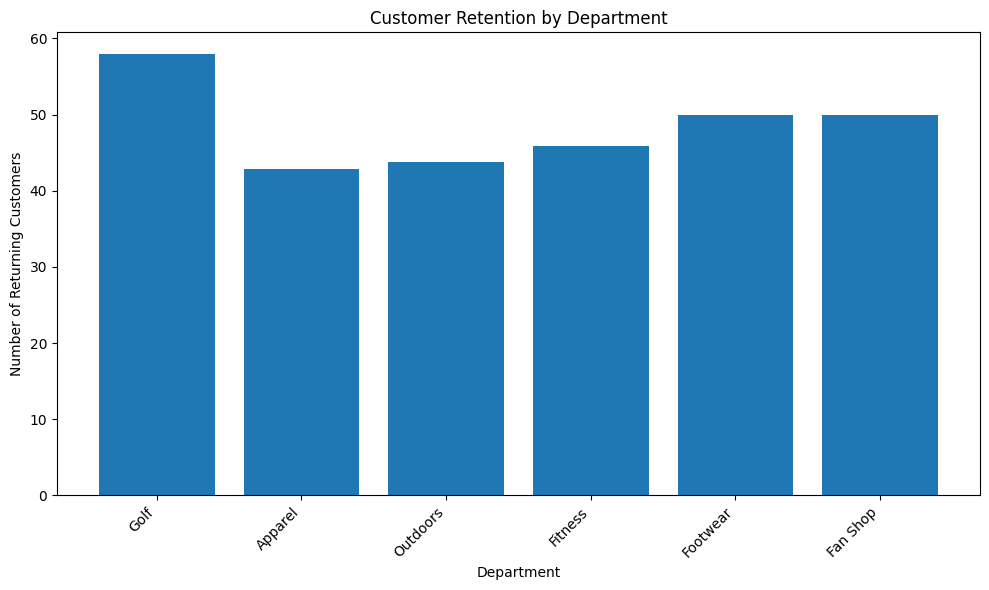

In [ ]:
# Visualising
departments = ["Golf", "Apparel", "Outdoors", "Fitness", "Footwear", "Fan Shop"]
retention_rates = [golf_retention_rate, apparel_retention_rate, outdoors_retention_rate, fitness_retention_rate, footwear_retention_rate, fan_shop_retention_rate]

plt.figure(figsize=(10, 6))
plt.bar(departments, retention_rates)
plt.xlabel("Department")
plt.ylabel("Number of Returning Customers")
plt.title("Customer Retention by Department")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
#Merging metrics dataframes for each department for comparison and visulisation

from pyspark.sql.functions import lit

# Create a list of DataFrames and their corresponding department names
department_metrics = [
    (golf_metrics_df, "Golf"),
    (apparel_metrics_df, "Apparel"),
    (outdoors_metrics_df, "Outdoors"),
    (fitness_metrics_df, "Fitness"),
    (footwear_metrics_df, "Footwear"),
    (fan_shop_metrics_df, "Fan Shop")
]

# Initialize an empty DataFrame to store the merged results
merged_metrics_df = None

# Iterate through the list of DataFrames and merge them
for df, dept_name in department_metrics:
  # Add a column to each DataFrame to indicate the department
  df_with_dept = df.withColumn("department", lit(dept_name))

  if merged_metrics_df is None:
    merged_metrics_df = df_with_dept
  else:
    merged_metrics_df = merged_metrics_df.union(df_with_dept)


merged_metrics_df.show()


+---------+--------------------+------------------+----------+------------------+-----------------+--------------------+-----------------+-------------------+---------------------+-------------------------+----------+
|dept_name|       total_revenue|   avg_order_value|num_orders|    avg_unit_price|num_products_sold|num_unique_customers|total_order_value|num_unique_products|num_unique_categories|avg_customer_satisfaction|department|
+---------+--------------------+------------------+----------+------------------+-----------------+--------------------+-----------------+-------------------+---------------------+-------------------------+----------+
|     Golf|  8227623.7500045495| 6898.733333333334|        40|114.68108333342595|           101250|                  19|        3.10443E8|                 69|                    5|        3.011311111111111|      Golf|
|  Apparel|1.1135047500008823E7| 6422.364285714286|        48|141.50900000015534|           116625|                  21|     3.3

In [ ]:
merged_metrics_df = merged_metrics_df.drop("department")
merged_metrics_df.show()

+---------+--------------------+------------------+----------+------------------+-----------------+--------------------+-----------------+-------------------+---------------------+-------------------------+
|dept_name|       total_revenue|   avg_order_value|num_orders|    avg_unit_price|num_products_sold|num_unique_customers|total_order_value|num_unique_products|num_unique_categories|avg_customer_satisfaction|
+---------+--------------------+------------------+----------+------------------+-----------------+--------------------+-----------------+-------------------+---------------------+-------------------------+
|     Golf|  8227623.7500045495| 6898.733333333334|        40|114.68108333342595|           101250|                  19|        3.10443E8|                 69|                    5|        3.011311111111111|
|  Apparel|1.1135047500008823E7| 6422.364285714286|        48|141.50900000015534|           116625|                  21|     3.37174125E8|                 83|              

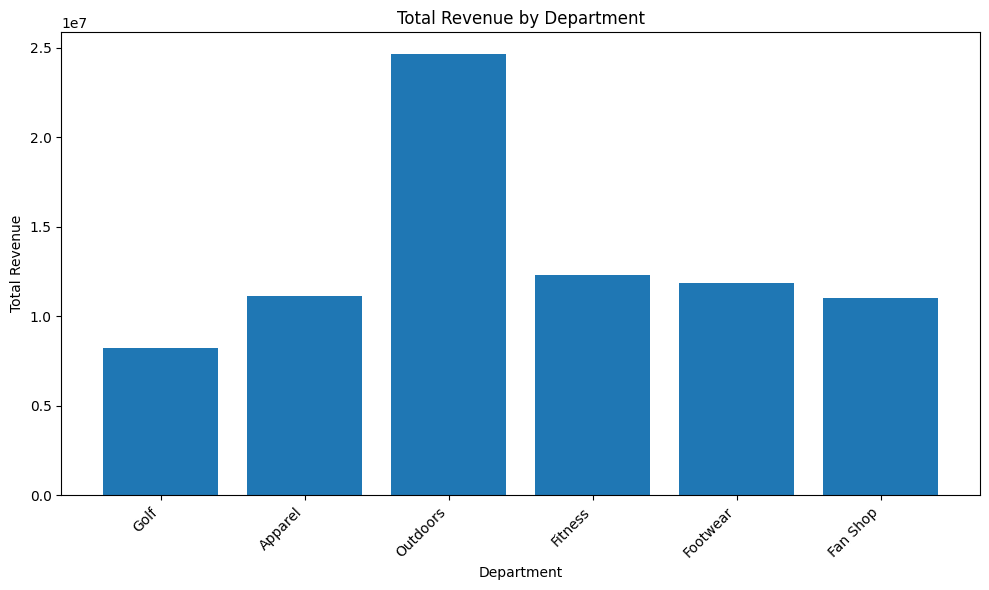

In [ ]:
# Barplot for total revenue by department
merged_metrics_pd = merged_metrics_df.toPandas()

# Create a bar plot of total revenue by department
plt.figure(figsize=(10, 6))
plt.bar(merged_metrics_pd["dept_name"], merged_metrics_pd["total_revenue"])
plt.xlabel("Department")
plt.ylabel("Total Revenue")
plt.title("Total Revenue by Department")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Bar Chart for Customer Satisfaction by department
plt.figure(figsize=(10, 6))
plt.bar(merged_metrics_pd["dept_name"], merged_metrics_pd["avg_customer_satisfaction"])
plt.xlabel("Department")
plt.ylabel("Average Customer Satisfaction")
plt.title("Average Customer Satisfaction by Department")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

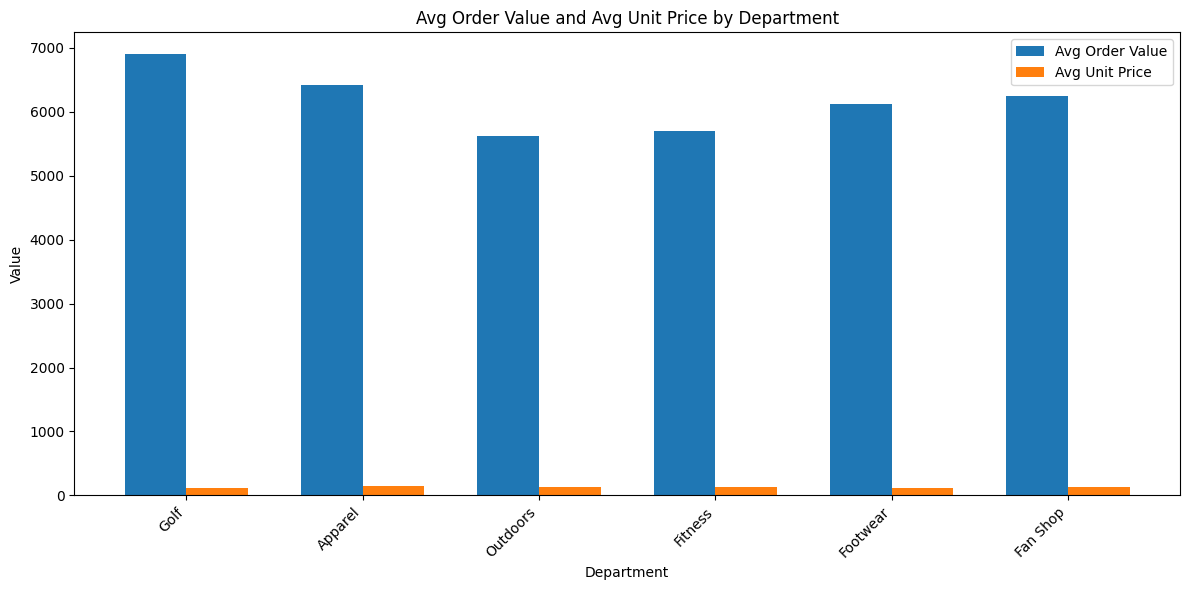

In [ ]:
# Clustered bar plot for avg order value and avg unit price
width = 0.35  # Width of the bars

plt.figure(figsize=(12, 6))
x = range(len(merged_metrics_pd["dept_name"]))
plt.bar([i - width / 2 for i in x], merged_metrics_pd["avg_order_value"], width, label="Avg Order Value")
plt.bar([i + width / 2 for i in x], merged_metrics_pd["avg_unit_price"], width, label="Avg Unit Price")

plt.xlabel("Department")
plt.ylabel("Value")
plt.title("Avg Order Value and Avg Unit Price by Department")
plt.xticks(x, merged_metrics_pd["dept_name"], rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()


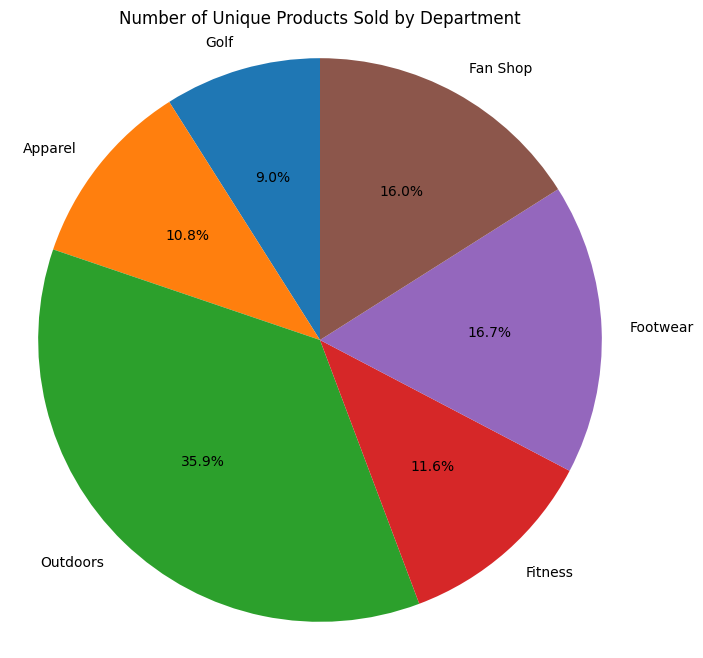

In [ ]:
#Pie Chart of num_unique_products sold by department

plt.figure(figsize=(8, 8))
plt.pie(merged_metrics_pd["num_unique_products"], labels=merged_metrics_pd["dept_name"], autopct='%1.1f%%', startangle=90)
plt.title("Number of Unique Products Sold by Department")
plt.axis('equal')
plt.show()


In [ ]:
#Merging status dataframes for each department for comparison and visulisation

# Create a list of DataFrames and their corresponding department names for status
department_status = [
    (golf_status_df, "Golf"),
    (apparel_status_df, "Apparel"),
    (outdoors_status_df, "Outdoors"),
    (fitness_status_df, "Fitness"),
    (footwear_status_df, "Footwear"),
    (fan_shop_status_df, "Fan Shop")
]

# Initialize an empty DataFrame to store the merged results
merged_status_df = None

# Iterate through the list of DataFrames and merge them
for df, dept_name in department_status:
  # Add a column to each DataFrame to indicate the department
  df_with_dept = df.withColumn("department", lit(dept_name))

  if merged_status_df is None:
    merged_status_df = df_with_dept
  else:
    merged_status_df = merged_status_df.union(df_with_dept)



+---------+---------+-----------+--------+---------+----------+
|dept_name|completed|pay pending|canceled|sus_fraud|department|
+---------+---------+-----------+--------+---------+----------+
|     Golf|       14|          6|       0|        0|      Golf|
|  Apparel|       12|         12|       0|        0|   Apparel|
| Outdoors|       37|         26|       0|        2|  Outdoors|
|  Fitness|       11|         16|       1|        1|   Fitness|
| Footwear|       21|         16|       1|        1|  Footwear|
| Fan Shop|       13|          9|       0|        2|  Fan Shop|
+---------+---------+-----------+--------+---------+----------+



In [ ]:
merged_status_df = merged_status_df.drop("department")
merged_status_df.show()

+---------+---------+-----------+--------+---------+
|dept_name|completed|pay pending|canceled|sus_fraud|
+---------+---------+-----------+--------+---------+
|     Golf|       14|          6|       0|        0|
|  Apparel|       12|         12|       0|        0|
| Outdoors|       37|         26|       0|        2|
|  Fitness|       11|         16|       1|        1|
| Footwear|       21|         16|       1|        1|
| Fan Shop|       13|          9|       0|        2|
+---------+---------+-----------+--------+---------+



**Performance Comparison Summary**

The "Outdoors" department has a high "pay pending" count - indicating more abandoned carts, it could indicate potential issues with delivery time estimations or customer uncertainty about product suitability for outdoor activities.

No departments have unusually many canceled orders but. If a department has a significantly higher "canceled" count compared to other departments, it might suggest problems with their sizing charts, returns policies, or the quality of their products.


Comparing suspected fraud orders across departments reveals which areas might require more attention regarding fraud prevention measures

In [ ]:
# Based on Total Revenue
top_revenue_dept = merged_metrics_df.orderBy(desc("total_revenue")).first()
print(f"Department with highest total revenue: {top_revenue_dept['dept_name']} with ${top_revenue_dept['total_revenue']}")

# Based on Average Order Value
top_avg_order_dept = merged_metrics_df.orderBy(desc("avg_order_value")).first()
print(f"Department with highest average order value: {top_avg_order_dept['dept_name']} with ${top_avg_order_dept['avg_order_value']}")


# Based on Number of Unique Products
top_unique_products_dept = merged_metrics_df.orderBy(desc("num_unique_products")).first()
print(f"Department with highest unique product offerings: {top_unique_products_dept['dept_name']} with {top_unique_products_dept['num_unique_products']} products")



Department with highest total revenue: Outdoors with $24618768.750001475
Department with highest average order value: Golf with $6898.733333333334
Department with highest unique product offerings: Outdoors with 276 products


Golf Department Customer Retention Rate: **57.89%**

Apparel Department Customer Retention Rate: **42.85%**

Outdoors Department Customer Retention Rate: **43.75%**

Based on overall sales, product diversity, and customer loyalty, it appears that **'Outdoors'** department may be performing better compared to other departments. Other departments - Fitness, Footwear, Apparel etc - have similar sales, retention, and satisfaction numbers with **Golf** department having the highest average value per order as well as the best customer retention of all. All departments perform simialrly in terms of customer satisfaction with all of them having satisfaction ratings ~ **2.99**, Golf inches slightly ahead with **3.01**.
However, it should be noted that each department's performance is unique and based on multiple factors.